## Agnieszka Kęska - układy nieliniowe i uczenie maszynowe

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
import pandas as pd


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\5agak\anaconda3\anaconda2\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\5agak\anaconda3\anaconda2\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\5agak\anaconda3\anaconda2\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [14]:
GOOG.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 2 to 1230
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            1229 non-null   datetime64[ns]
 1   Close           1229 non-null   float64       
 2   High            1229 non-null   float64       
 3   Low             1229 non-null   float64       
 4   Open            1229 non-null   float64       
 5   Volume          1229 non-null   int64         
 6   Year            1229 non-null   int32         
 7   Month           1229 non-null   int32         
 8   Day             1229 non-null   int32         
 9   Weekday         1229 non-null   int32         
 10  DaysSinceStart  1229 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int32(4), int64(2)
memory usage: 86.5 KB


In [88]:
GOOG = pd.read_csv('GOOG_history1.csv').iloc[2:,].rename(columns = {'Price':'Date'})
cols = ["Close", "High", "Low", "Open", "Volume"]
GOOG["Date"] = pd.to_datetime(GOOG["Date"])
for c in cols:
    GOOG[c] = pd.to_numeric(GOOG[c], errors="coerce")
    GOOG["Date"] = pd.to_datetime(GOOG["Date"])
GOOG["Year"] = GOOG["Date"].dt.year
GOOG["Month"] = GOOG["Date"].dt.month
GOOG["Day"] = GOOG["Date"].dt.day
GOOG["Weekday"] = GOOG["Date"].dt.weekday
GOOG["DaysSinceStart"] = (GOOG["Date"] - GOOG["Date"].min()).dt.days

In [54]:
num_days = len(GOOG)
print("Liczba dni danych:", num_days)

# Sprawdzenie równomierności dat
GOOG = GOOG.sort_values("Date")
GOOG["DiffDays"] = GOOG["Date"].diff().dt.days
print("Różnice między kolejnymi dniami:\n", GOOG["DiffDays"].value_counts())

Liczba dni danych: 1229
Różnice między kolejnymi dniami:
 DiffDays
1.0    963
3.0    219
4.0     35
2.0     11
Name: count, dtype: int64


## Przetworzenie danych

Dane giełdowe zostały pobrane dla trzech spółek: Google, Apple, Microsoft. Zawierją informacje takie jak data, cena zamknięcia, otwarcia,najniższa cena, najwyższa cena oraz wolumen. Dane obejmują 1229 dni z lat 2021-2025. Większość różnic między kolejnymi dniami wynosi 1 lub 3 dni, co odpowiada dniom roboczym i weekendom, z nielicznymi większymi odstępami (święta). Dane są więc względnie jednorodne w czasie.Braki danych nie występują. Natomiast typ zmiennych trzeba było zmienić na numerical. Dodałam też kolumny powstające na podstawie daty, takie jak Year,month,Day,Weekday, oraz DaySince start aby okreslić kojeność czasową.

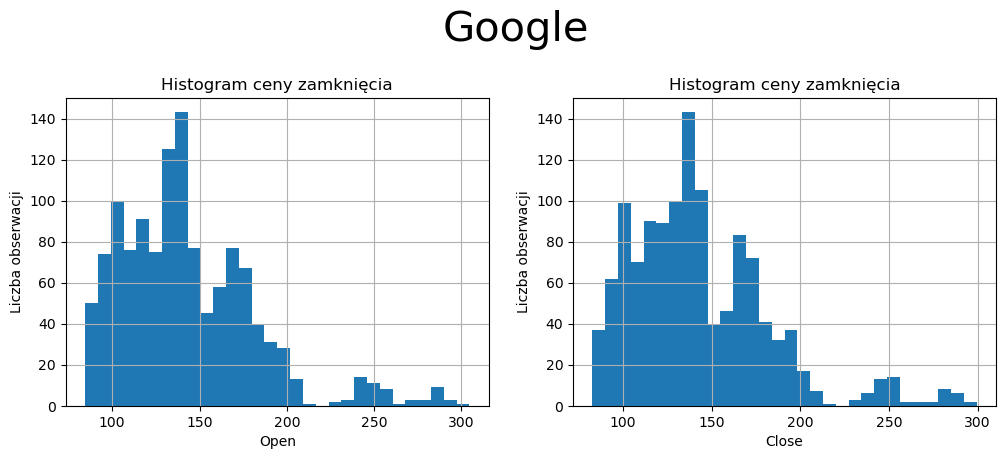

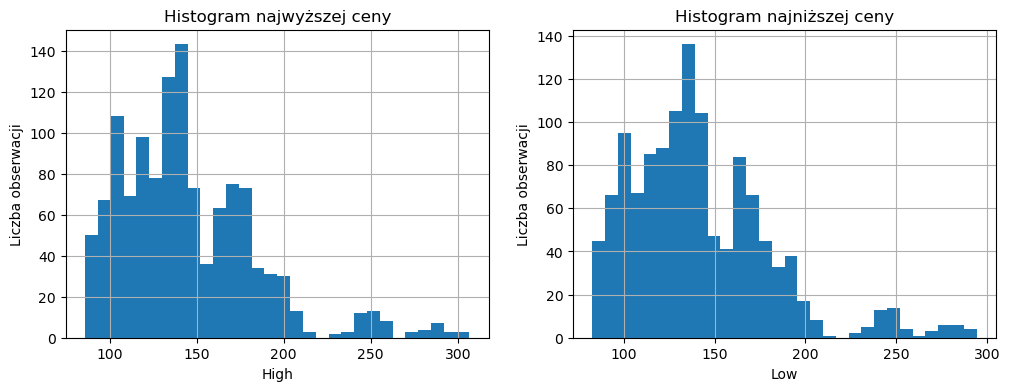

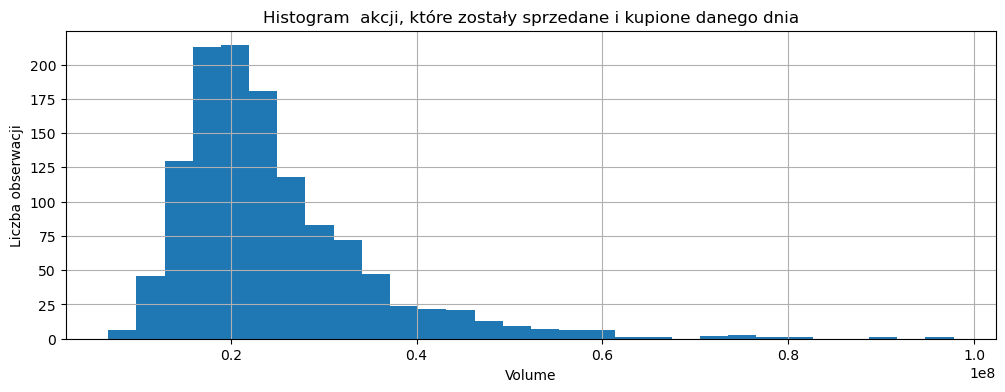

In [57]:
plt.figure(figsize = (12,4))
plt.suptitle('Google',fontsize = 30,y=1.1)

plt.subplot(1,2,1)
GOOG["Open"].hist(bins=30)
plt.title("Histogram ceny zamknięcia")
plt.xlabel("Open")
plt.ylabel("Liczba obserwacji")
plt.subplot(1,2,2)
GOOG["Close"].hist(bins=30)
plt.title("Histogram ceny zamknięcia")
plt.xlabel("Close")
plt.ylabel("Liczba obserwacji")
plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
GOOG["High"].hist(bins=30)
plt.title("Histogram najwyższej ceny")
plt.xlabel("High")
plt.ylabel("Liczba obserwacji")
plt.subplot(1,2,2)
GOOG["Low"].hist(bins=30)
plt.title("Histogram najniższej ceny")
plt.xlabel("Low")
plt.ylabel("Liczba obserwacji")

plt.figure(figsize = (12,4))
GOOG["Volume"].hist(bins=30)
plt.title("Histogram  akcji, które zostały sprzedane i kupione danego dnia")
plt.xlabel("Volume")
plt.ylabel("Liczba obserwacji")
plt.show()



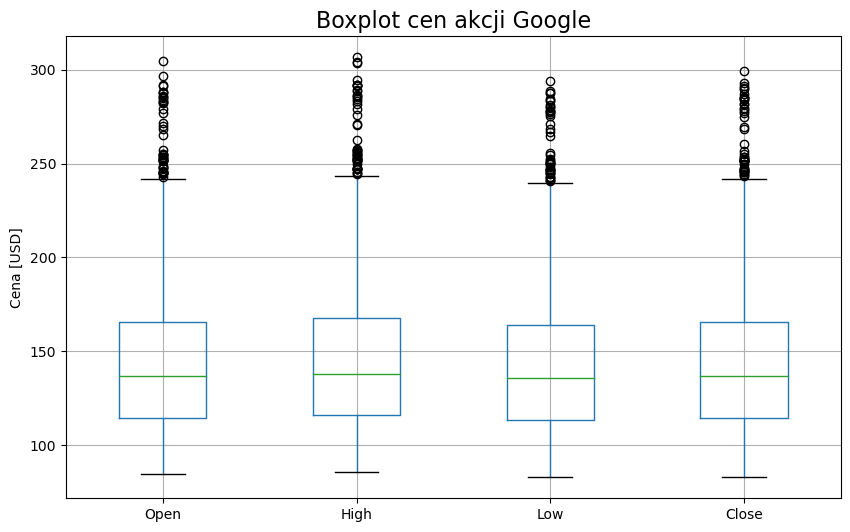

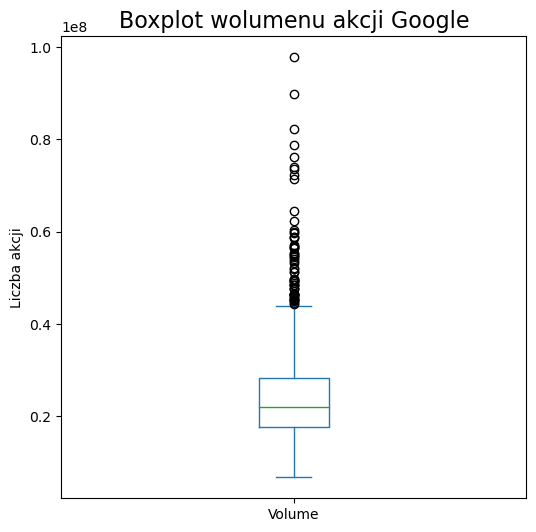

In [58]:
plt.figure(figsize=(10,6))
GOOG[["Open", "High", "Low", "Close"]].boxplot()
plt.title("Boxplot cen akcji Google", fontsize=16)
plt.ylabel("Cena [USD]")
plt.show()
plt.figure(figsize=(6,6))
GOOG["Volume"].plot.box()
plt.title("Boxplot wolumenu akcji Google", fontsize=16)
plt.ylabel("Liczba akcji")
plt.show()

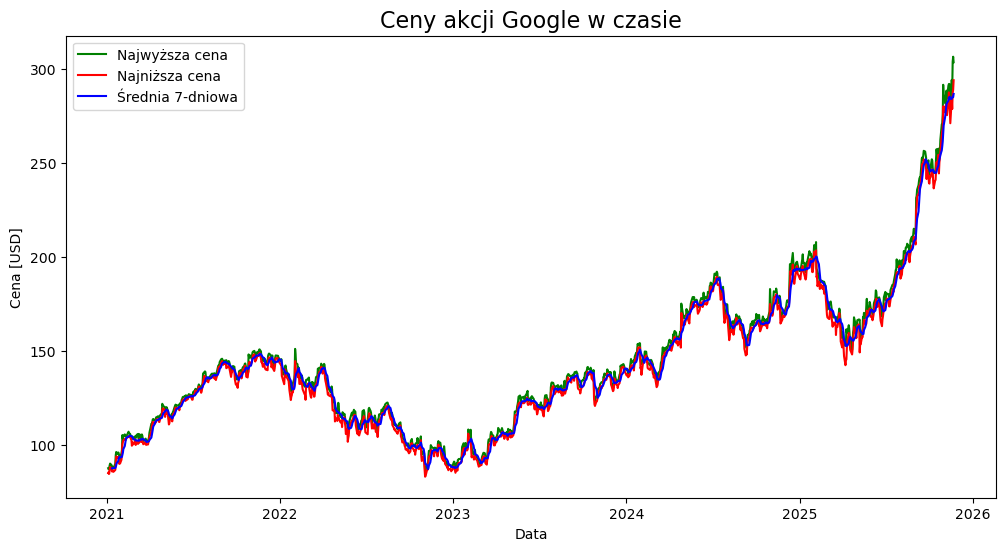

In [59]:
plt.figure(figsize=(12,6))
plt.plot(GOOG["Date"], GOOG["High"], label="Najwyższa cena", color="green")
plt.plot(GOOG["Date"], GOOG["Low"], label="Najniższa cena", color="red")
plt.plot(GOOG["Date"], GOOG["Close"].rolling(window=7).mean(), label="Średnia 7-dniowa", color="blue")
plt.title("Ceny akcji Google w czasie", fontsize=16)
plt.xlabel("Data")
plt.ylabel("Cena [USD]")
plt.legend()
plt.show()

                    Open      High       Low     Close    Volume       Day  \
Open            1.000000  0.999303  0.999212  0.998433 -0.240551  0.018771   
High            0.999303  1.000000  0.999187  0.999262 -0.231886  0.015775   
Low             0.999212  0.999187  1.000000  0.999428 -0.254249  0.016682   
Close           0.998433  0.999262  0.999428  1.000000 -0.245638  0.014326   
Volume         -0.240551 -0.231886 -0.254249 -0.245638  1.000000  0.055999   
Day             0.018771  0.015775  0.016682  0.014326  0.055999  1.000000   
Month           0.228883  0.227297  0.230514  0.228747 -0.217314 -0.004464   
Year            0.700449  0.703033  0.699253  0.701381 -0.169743 -0.000611   
DaysSinceStart  0.739488  0.741677  0.738593  0.740305 -0.210383  0.015408   

                   Month      Year  DaysSinceStart  
Open            0.228883  0.700449        0.739488  
High            0.227297  0.703033        0.741677  
Low             0.230514  0.699253        0.738593  
Close  

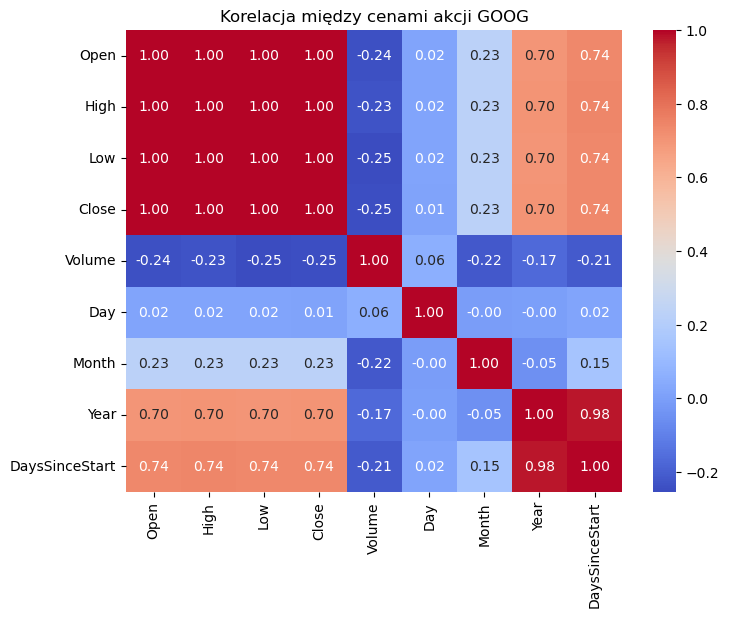

In [60]:
price_cols = ["Open", "High", "Low", "Close",'Volume','Day','Month','Year','DaysSinceStart']
price_data = GOOG[price_cols]
corr_matrix = price_data.corr()
print(corr_matrix)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelacja między cenami akcji GOOG")
plt.show()